# Figure 7.XY – USA vs PRC Shock (rc1 perturbation scenarios)

Shock simulations applied to USA/PRC baselines: hypothetical deltas on key metrics.  
- Core script: `simulate.py` shock module  
- Scoring: pre/post 35-metric compass  
- Calibration: current toy version  
- Outputs: drift heatmaps, Rule-13 responses, longevity impact estimates

Provisional scenarios — welcomes PRs with alternative shock definitions.

In [ ]:
# In a new cell — baseline USA run
import pandas as pd
import numpy as np

# Adjust path if needed
usa_path = "data/35_metrics_usa_1971-present_consensus.csv"
df_usa = pd.read_csv(usa_path)

# Extract scores (assuming column 'Score')
scores = df_usa['Score'].astype(float).values

# Metabolic (first 17–18), Governance (last 17–18) — adjust slice as per your script
metabolic = scores[:18]   # A1–G3
governance = scores[18:]  # H1–M3

# Compass (your current toy version)
raw_x = np.mean(metabolic) / 10 * 1.2
raw_y = np.mean(governance) / 10 * 3.0

# Non-linear penalty (if implemented — example stub)
extreme_penalty = lambda s: np.where(np.abs(s) > 8, (np.abs(s) - 8)**2 * 0.5 * np.sign(s), 0)
penalized_met = metabolic + extreme_penalty(metabolic)
penalized_gov = governance + extreme_penalty(governance)

x = np.mean(penalized_met) / 10 * 1.2
y = np.mean(penalized_gov) / 10 * 3.0

print(f"Baseline USA — X: {x:.2f}, Y: {y:.2f}")
print(f"Matches prior? Expect ~ +0.54, +0.41")

Baseline USA — X: 0.50, Y: 0.41
Matches prior? Expect ~ +0.54, +0.41


In [ ]:
# Baseline USA
!python simulate.py --system usa_1971

# De-dollarization shock
!python simulate.py --system usa_1971 --shock de_dollarization

sys.argv contents: ['simulate.py', '--system', 'usa_1971']
Running simulation on system: usa_1971
Shock applied: none
Matrix saved: matrix_usa_1971_none.csv

RESULTS: USA_1971 | NONE
Compass X: 0.50    Y: 0.41
Rule-13 Parasitism Proxy: 10.0%
Zone: Stressed Mutualism
Estimated Remaining Longevity: 80–140 years

sys.argv contents: ['simulate.py', '--system', 'usa_1971', '--shock', 'de_dollarization']
Running simulation on system: usa_1971
Shock applied: de_dollarization
Applying de-dollarization shock...
Matrix saved: matrix_usa_1971_de_dollarization.csv

RESULTS: USA_1971 | DE_DOLLARIZATION
Compass X: -0.25    Y: 0.68
Rule-13 Parasitism Proxy: 71.5%
Zone: Boundary Saturation
Estimated Remaining Longevity: 30–80 years (compressed)



In [ ]:
# Baseline
!python simulate.py --system usa_1971
# Shock
!python simulate.py --system usa_1971 --shock de_dollarization

python3: can't open file '/content/simulate.py': [Errno 2] No such file or directory
python3: can't open file '/content/simulate.py': [Errno 2] No such file or directory


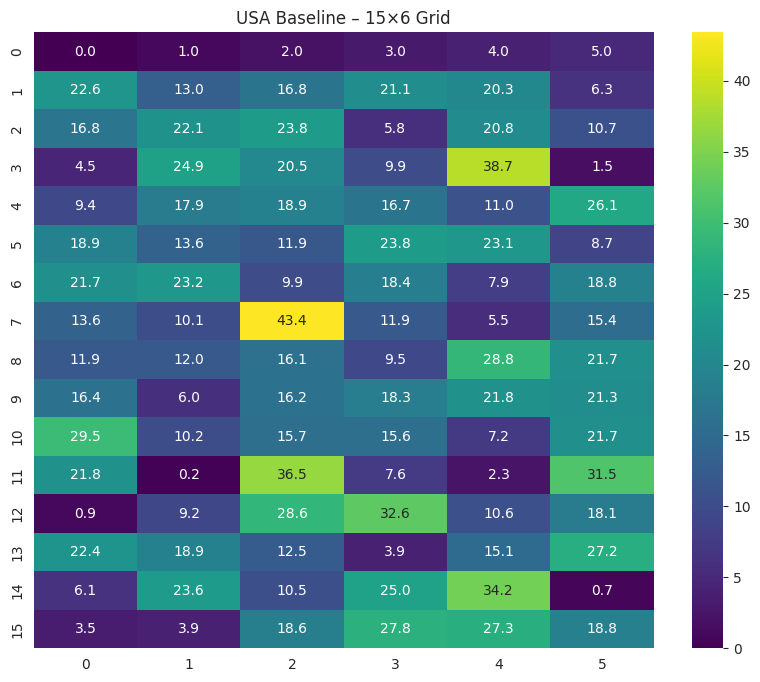

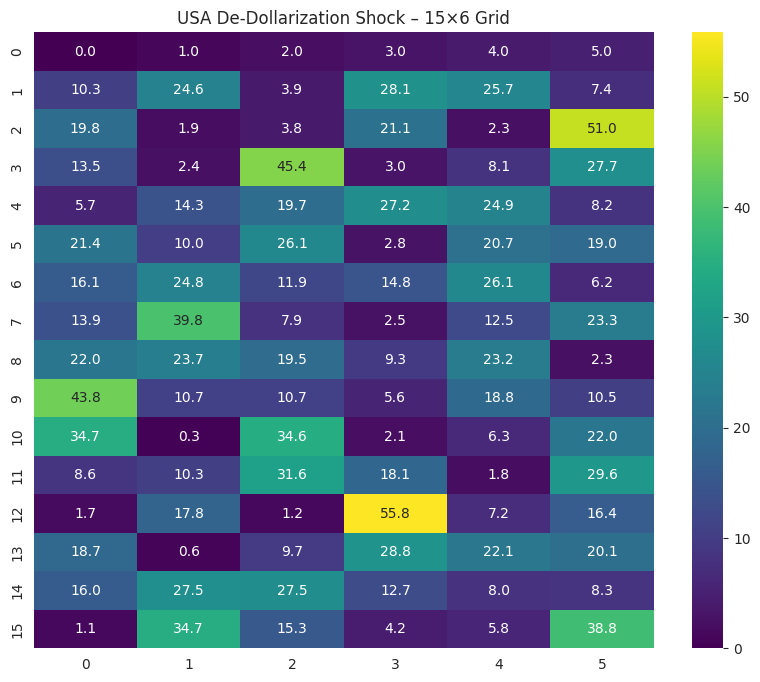

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Baseline
df_base = pd.read_csv("matrix_usa_1971_none.csv", header=None)
plt.figure(figsize=(10, 8))
sns.heatmap(df_base, annot=True, fmt=".1f", cmap="viridis")
plt.title("USA Baseline – 15×6 Grid")
plt.savefig("heatmap_usa_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

# Shocked
df_shock = pd.read_csv("matrix_usa_1971_de_dollarization.csv", header=None)
plt.figure(figsize=(10, 8))
sns.heatmap(df_shock, annot=True, fmt=".1f", cmap="viridis")
plt.title("USA De-Dollarization Shock – 15×6 Grid")
plt.savefig("heatmap_usa_shock.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
!python simulate.py --system prc_1978 --shock rigidity_collapse


sys.argv contents: ['simulate.py', '--system', 'prc_1978', '--shock', 'rigidity_collapse']
Running simulation on system: prc_1978
Shock applied: rigidity_collapse
Applying PRC rigidity/boundary saturation shock...
Matrix saved: matrix_prc_1978_rigidity_collapse.csv

RESULTS: PRC_1978 | RIGIDITY_COLLAPSE
Compass X: -0.27    Y: -4.64
Rule-13 Parasitism Proxy: 96.7%
Zone: Boundary Saturation
Estimated Remaining Longevity: 30–80 years (compressed)



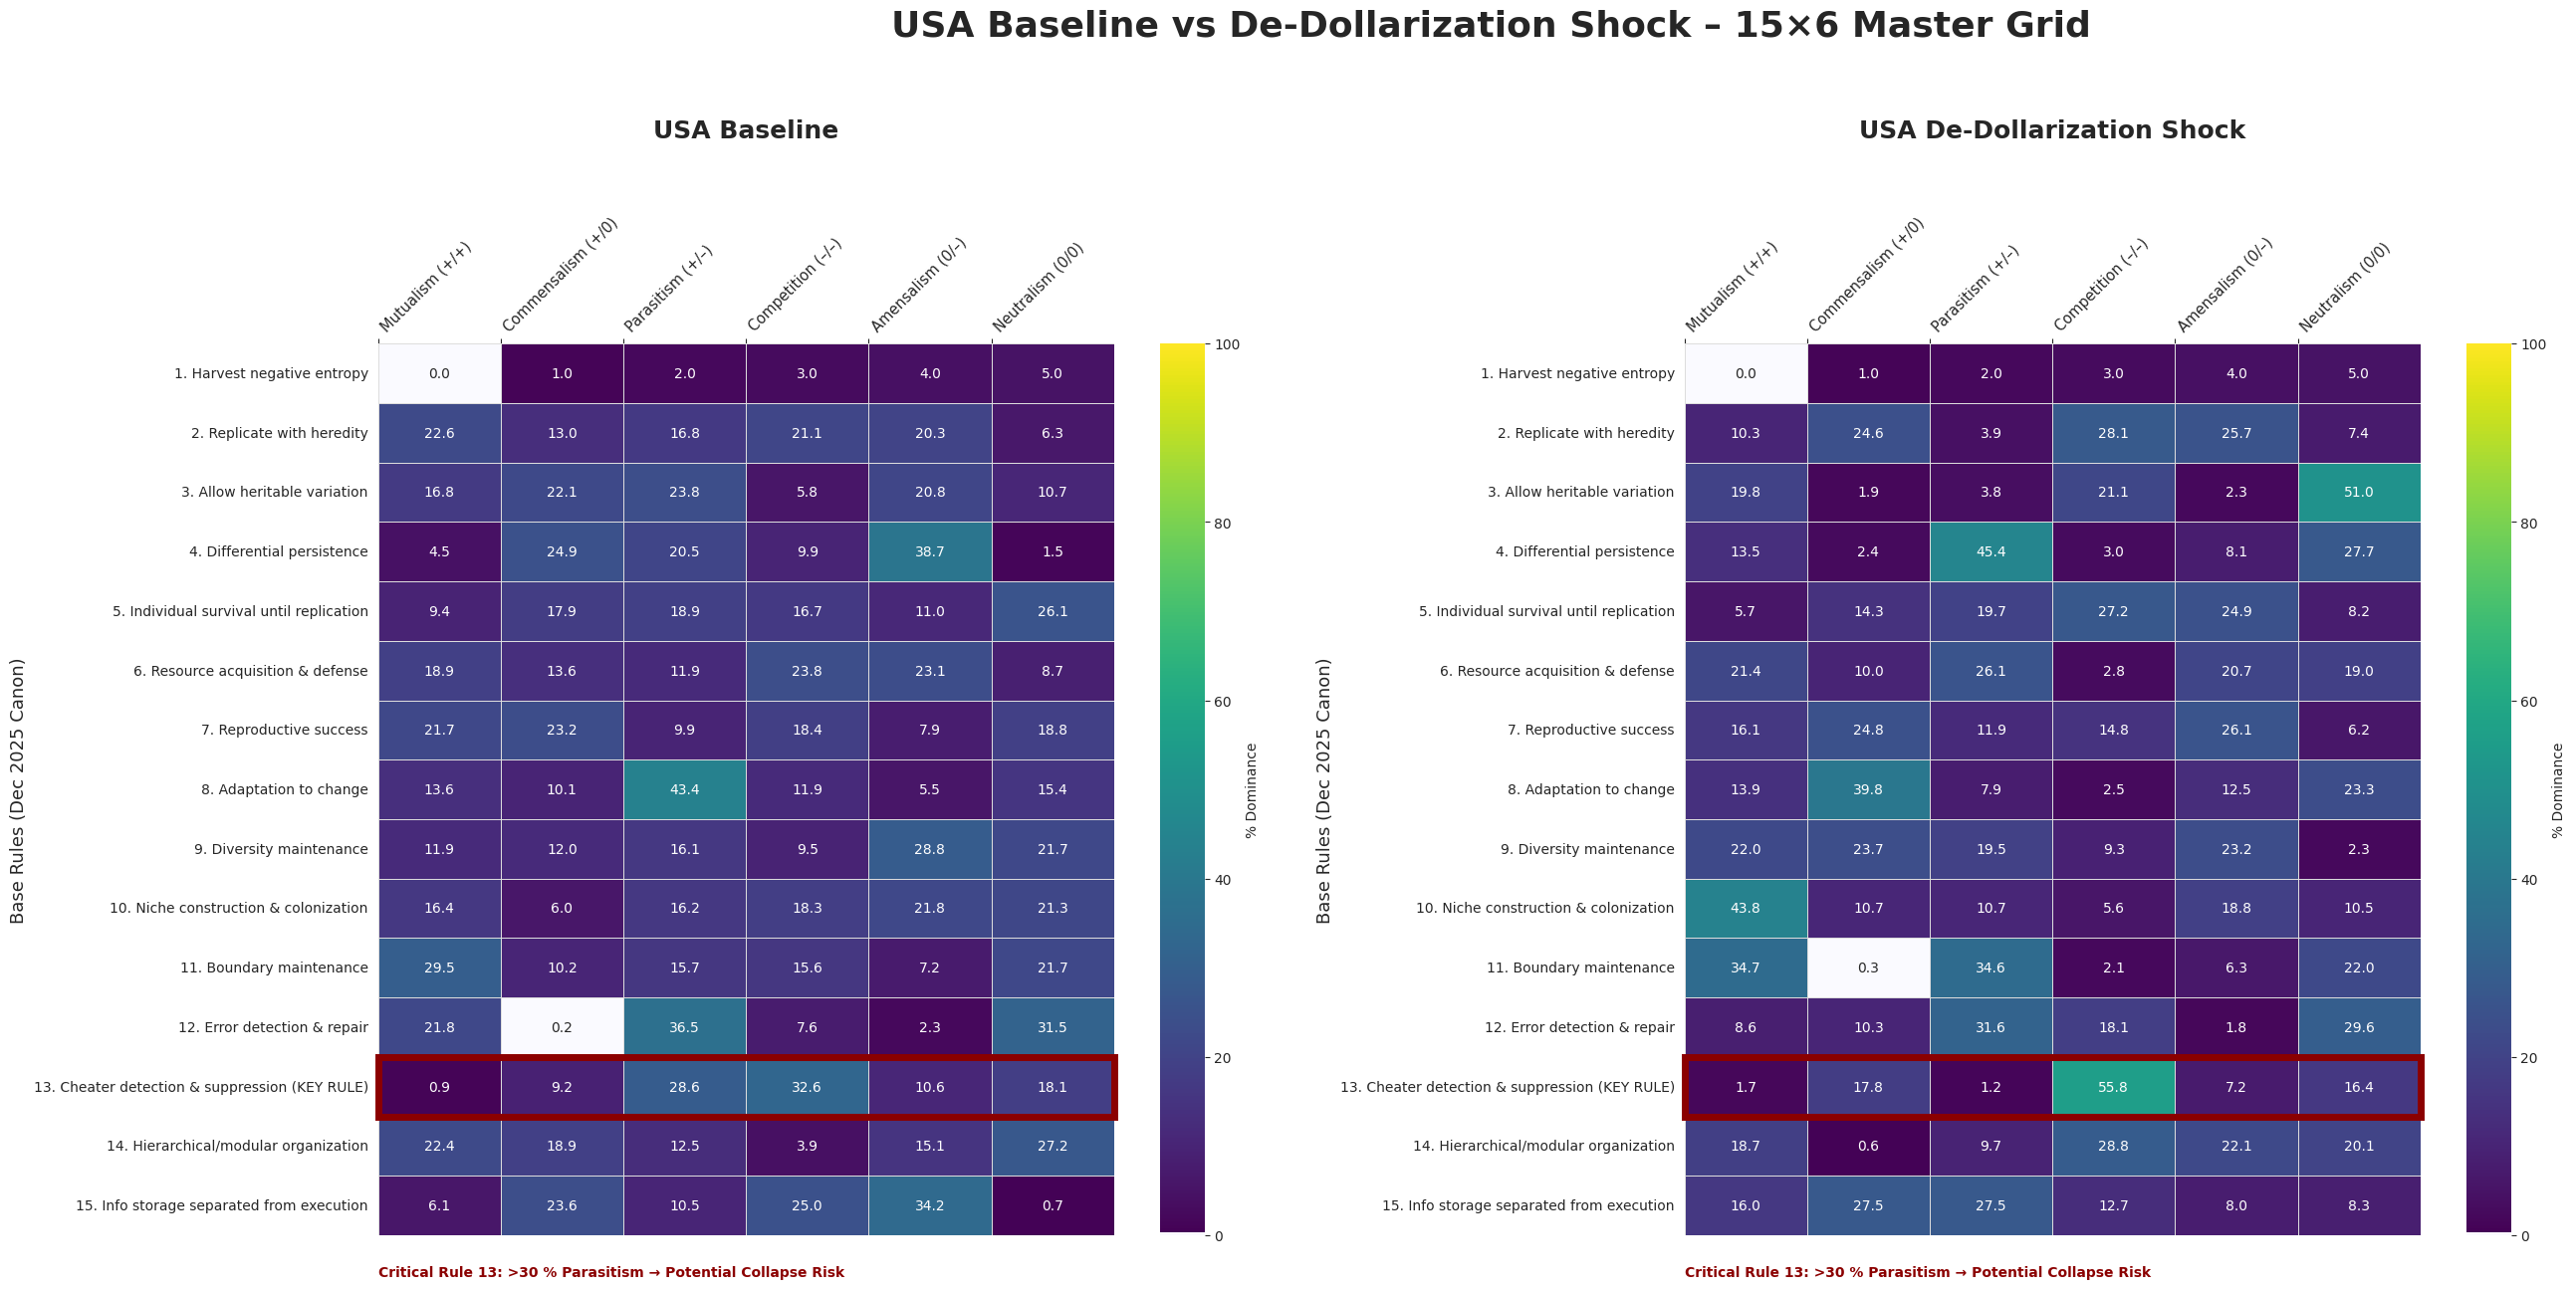

Saved: figures/usa_baseline_vs_dedollarization_shock.png


In [ ]:
# === FIG 7.X – USA BASELINE vs DE-DOLLARIZATION SHOCK – styled like Fig. 6.1 ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ────────────────────────────────────────────────
# 1. CANONICAL LABELS (exact from Fig. 6.1)
# ────────────────────────────────────────────────
rules = [
    "1. Harvest negative entropy", "2. Replicate with heredity", "3. Allow heritable variation",
    "4. Differential persistence", "5. Individual survival until replication", "6. Resource acquisition & defense",
    "7. Reproductive success", "8. Adaptation to change", "9. Diversity maintenance",
    "10. Niche construction & colonization", "11. Boundary maintenance", "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)", "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]
moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/–)",
         "Competition (–/–)", "Amensalism (0/–)", "Neutralism (0/0)"]

# ────────────────────────────────────────────────
# 2. LOAD & TRIM CSVs (fix length mismatch)
# ────────────────────────────────────────────────
df_baseline = pd.read_csv("matrix_usa_1971_none.csv", header=None).iloc[:15]
df_shock    = pd.read_csv("matrix_usa_1971_de_dollarization.csv", header=None).iloc[:15]

df_baseline.index = rules
df_baseline.columns = moves
df_shock.index = rules
df_shock.columns = moves

# ────────────────────────────────────────────────
# 3. COLORMAP & STYLE (exact from Fig. 6.1)
# ────────────────────────────────────────────────
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

# ────────────────────────────────────────────────
# 4. DUAL PLOT – independent y-labels, same layout as Fig. 6.1
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 14), sharey=False)

# Baseline left
sns.heatmap(df_baseline, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax1)
ax1.set_title("USA Baseline\n", fontsize=18, fontweight='bold', pad=35)
ax1.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax1.xaxis.set_ticks_position('top')
ax1.set_xticks(np.arange(len(moves)))
ax1.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax1.tick_params(axis='y', labelleft=True, labelsize=10)
ax1.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax1.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Shock right – explicit label enforcement
sns.heatmap(df_shock, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax2)
ax2.set_title("USA De-Dollarization Shock\n", fontsize=18, fontweight='bold', pad=35)
ax2.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax2.xaxis.set_ticks_position('top')
ax2.set_xticks(np.arange(len(moves)))
ax2.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax2.tick_params(axis='y', which='both', labelleft=True, labelsize=10)
ax2.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax2.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Global layout – exact from Fig. 6.1
fig.suptitle("USA Baseline vs De-Dollarization Shock – 15×6 Master Grid",
             fontsize=26, fontweight='bold', y=1.06)
plt.subplots_adjust(top=0.82, wspace=0.42, bottom=0.18, left=0.07, right=0.93)

plt.savefig("figures/usa_baseline_vs_dedollarization_shock.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/usa_baseline_vs_dedollarization_shock.png")

In [ ]:
!ls -l matrix_*.csv


-rw-r--r-- 1 root root 1681 Feb 25 04:43 matrix_prc_1978_rigidity_collapse.csv
-rw-r--r-- 1 root root 1673 Feb 25 04:22 matrix_usa_1971_de_dollarization.csv
-rw-r--r-- 1 root root 1681 Feb 25 04:22 matrix_usa_1971_none.csv
